# 06_Unsupervised_Model_Development_K-Means

In [23]:
# pip install --upgrade ipywidgets jupyter

In [57]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import MiniBatchKMeans
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD
import umap
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)


In [25]:
# Load the parquet file
INPUT_PATH = '../data/processed/processed_narratives.parquet'
df_narratives = pd.read_parquet(INPUT_PATH)

In [26]:
df_narratives.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID,cleaned_consumer_narrative,processed_narrative
0,2019-11-18,Credit card or prepaid card,General-purpose credit card or charge card,Problem with a purchase shown on your statement,Credit card company isn't resolving a dispute ...,XXXX claimed they delivered a package to my ad...,NaN,DISCOVER BANK,MA,021XX,NaN,Consent provided,Web,2019-11-18,Closed with explanation,True,N/A,3442136,REDACTED claimed they delivered a package to m...,claimed delivered package address never receiv...
1,2020-04-10,Credit card or prepaid card,General-purpose prepaid card,Trouble using the card,Trouble getting information about the card,I got a Brinks Money pre-paid card in the mail...,Company has responded to the consumer and the ...,Netspend Corporation,IL,60657,NaN,Consent provided,Web,2020-04-14,Closed with explanation,True,N/A,3601853,I got a Brinks Money pre-paid card in the mail...,got brink money pre paid card mail assuming un...
2,2019-07-09,Credit card or prepaid card,Store credit card,Problem with a purchase shown on your statement,Card was charged for something you did not pur...,On XX/XX/XXXX I was called by a creditor Nelso...,NaN,Nelson Cruz & Associates LLC,TN,37043,NaN,Consent provided,Web,2019-07-09,Closed with explanation,True,N/A,3300820,On REDACTED_DATE I was called by a creditor Ne...,called creditor nelson cruz associate claimed ...
3,2020-07-10,Credit card or prepaid card,General-purpose credit card or charge card,Trouble using your card,Can't use card to make purchases,Around XX/XX/2020 i XXXX XXXX XXXX opened a cr...,NaN,CAPITAL ONE FINANCIAL CORPORATION,CA,937XX,NaN,Consent provided,Web,2020-07-10,Closed with explanation,True,N/A,3739698,Around REDACTED / REDACTED /2020 i REDACTED RE...,around opened credit card account online capit...
4,2019-06-24,Credit card or prepaid card,General-purpose credit card or charge card,"Advertising and marketing, including promotion...",Confusing or misleading advertising about the ...,Equifax sent me credit card suggestions to hel...,NaN,"EQUIFAX, INC.",OR,971XX,NaN,Consent provided,Web,2019-06-24,Closed with explanation,True,N/A,3285243,Equifax sent me credit card suggestions to hel...,equifax sent credit card suggestion help impro...


In [27]:
# Drop duplicate narratives
starting_records = len(df_narratives)

df_narratives = (
    df_narratives
    .drop_duplicates(subset=['processed_narrative'])
    .reset_index(drop=True)
)

ending_records = len(df_narratives)

print(f'Records before dropping duplicates: {starting_records:,}')
print(f'Duplicate narratives removed: {starting_records - ending_records:,}')
print(f'Records after dropping duplicates: {ending_records:,}')

Records before dropping duplicates: 419,635
Duplicate narratives removed: 21,631
Records after dropping duplicates: 398,004


In [28]:
# jpmorgan_count = (
#     df_narratives['processed_narrative']
#     .str.contains(r'\bjpmorgan\b', regex=True, na=False)
#     .sum()
# )
#
# print(f"Records containing 'jpmorgan': {jpmorgan_count:,}")

In [29]:
# domain_stopwords = {
#     'goldman',
#     'sachs',
#     'one',
#     'chase',
#     'well',
#     'fargo',
#     'capital',
#     'america',
#     'citibank',
#     'citi',
#     'jpmorgan',
#     'navy',
#     'federal',
#     'union',
#     'card',
#     'credit',
#     'account',
#     'bank',
# }
#
# custom_stopwords = ENGLISH_STOP_WORDS.union(domain_stopwords)

In [30]:
# Get TF-IDF weights
### UNCOMMENT stop_words if you're using them ###
tfidf = TfidfVectorizer(
    # stop_words=list(custom_stopwords),
    min_df=10,
    max_df=0.95,
    max_features=20000,
    ngram_range=(1, 2),
)

X_tfidf = tfidf.fit_transform(df_narratives['processed_narrative'])

print(X_tfidf.shape)

(398004, 20000)


In [31]:
# Verify regularization
print(tfidf.norm)

l2


In [32]:
# Get top TF-IDF terms
feature_names = np.array(tfidf.get_feature_names_out())

mean_tfidf = np.asarray(X_tfidf.mean(axis=0)).ravel()

top_tfidf_terms = (
    pd.DataFrame({
        'term': feature_names,
        'mean_tfidf': mean_tfidf
    })
    .sort_values('mean_tfidf', ascending=False)
)

top_tfidf_terms.head(25)

,term,mean_tfidf
121,account,0.051974
3260,card,0.035932
5360,credit,0.034115
2229,bank,0.033272
12925,payment,0.027906
3777,charge,0.021001
19588,would,0.019609
11298,money,0.019200
4057,check,0.018541
17741,time,0.018172


In [33]:
# # Try StandardScaler before clustering
#
# scaler = StandardScaler(with_mean=False)
#
# X_tfidf_scaled = scaler.fit_transform(X_tfidf)
#
# k = 50
#
# kmeans = MiniBatchKMeans(
#     n_clusters=k,
#     random_state=42,
#     batch_size=1000,
#     n_init='auto'
# )
#
# clusters = kmeans.fit_predict(X_tfidf_scaled)
#
# df_narratives['cluster'] = clusters
#
# df_narratives['cluster'].value_counts().sort_index()

In [58]:
# Try different parameters for K-Means
# I initially ran k = 10, 30, and 50. I saw 50 had the highest silhouette, so I selected a higher range to try for number of
# clusters.
param_grid = {
    'n_clusters': [20, 30, 40, 50, 60, 75],
    'batch_size': [1000, 3000, 5000],
    'n_init': ['auto']
}

sample_idx = np.random.RandomState(42).choice(
    X_tfidf.shape[0],
    size=10000,
    replace=False
)

X_sample_sparse = X_tfidf[sample_idx]
X_sample_dense = X_sample_sparse.toarray()

results = []

for k in param_grid['n_clusters']:
    for batch_size in param_grid['batch_size']:
        for n_init in param_grid['n_init']:

            model = MiniBatchKMeans(
                n_clusters=k,
                batch_size=batch_size,
                n_init=n_init,
                random_state=42
            )

            cluster_labels = model.fit_predict(X_tfidf)
            cluster_sample = cluster_labels[sample_idx]

            results.append({
                'n_clusters': k,
                'batch_size': batch_size,
                'n_init': n_init,
                'inertia': model.inertia_,
                'silhouette_cosine': silhouette_score(
                    X_sample_sparse,
                    cluster_sample,
                    metric='cosine'
                ),
                'davies_bouldin': davies_bouldin_score(
                    X_sample_dense,
                    cluster_sample
                ),
                'calinski_harabasz': calinski_harabasz_score(
                    X_sample_dense,
                    cluster_sample
                )
            })

results_df = (
    pd.DataFrame(results)
    .sort_values(
        by=['silhouette_cosine', 'davies_bouldin', 'calinski_harabasz'],
        ascending=[False, True, False]
    )
)

results_df

,n_clusters,batch_size,n_init,inertia,silhouette_cosine,davies_bouldin,calinski_harabasz
12,60,1000,auto,356445.476258,0.031941,6.275379,17.187984
10,50,3000,auto,357856.442671,0.029991,6.467930,16.699667
7,40,3000,auto,359384.464993,0.029956,6.672955,19.066508
15,75,1000,auto,355222.595360,0.029474,6.045200,15.628332
13,60,3000,auto,355045.678717,0.029264,6.386349,15.479900
16,75,3000,auto,352517.866558,0.028836,6.155094,13.834210
4,30,3000,auto,362131.571183,0.028135,7.048299,22.707381
6,40,1000,auto,360355.359535,0.027580,6.673292,19.544219
8,40,5000,auto,359778.781362,0.027485,6.769798,18.933298
11,50,5000,auto,357221.528293,0.026011,6.661243,16.827700


In [59]:
# Run K-Means with k = 60 based on the parameter search
k = 60

kmeans = MiniBatchKMeans(
    n_clusters=k,
    random_state=42,
    batch_size=1000,
    n_init='auto'
)

df_narratives['cluster'] = kmeans.fit_predict(X_tfidf)
df_narratives['cluster'].value_counts().sort_index()

cluster
0      3852
1       497
2         1
3     45850
4      1166
5      2912
6     23631
7      2735
8         2
9      2682
10    10771
11    12998
12    10705
13     1379
14        1
15    10847
16     8986
17        1
18    11349
19     2209
20     5364
21     1695
22    11651
23     4408
24     1664
25    14668
26     6900
27        1
28     3134
29        1
30        1
31     2126
32    10975
33        1
34     6427
35    15604
36     5717
37     4491
38     6356
39     5635
40    13208
41     4910
42     6413
43     5717
44    23788
45    12061
46     4354
47     3795
48        1
49    11878
50     2580
51      736
52    14365
53     1611
54        1
55     8323
56     3186
57     3195
58     3797
59    14692
Name: count, dtype: int64

In [60]:
# Get top terms for each cluster
terms = np.array(tfidf.get_feature_names_out())

for cluster_num in range(k):
    top_indices = kmeans.cluster_centers_[cluster_num].argsort()[::-1][:15]
    top_terms = terms[top_indices]

    print(f'\nCluster {cluster_num}')
    print(', '.join(top_terms))


Cluster 0
payment, plan, monthly, month, monthly payment, pay, payment plan, minimum, interest, would, minimum payment, credit, due, amount, balance

Cluster 1
deposit, failure deposit, timely access, requires timely, right upheld, deposit direct, one failure, capital one, capital, assistance investigating, cited technical, ensure right, fund situation, investigating matter, concern consumer

Cluster 2
balance, interest balance, balance paid, interest, statement, left balance, previous statement, paid told, balance new, statement charged, new statement, would reverse, charge despite, last statement, charging interest

Cluster 3
account, bank, closed, year, company, time, credit, card, information, access, received, open, never, without, email

Cluster 4
machine, atm, atm machine, money, deposit, cash, bank, claim, went, deposited, receipt, back, branch, bill, account

Cluster 5
apple, goldman, sachs, goldman sachs, apple card, card, dispute, credit, charge, account, card goldman, sach

In [61]:
# # Calculate silhouette score
# sample_idx = df_narratives.sample(
#     n=10000,
#     random_state=42
# ).index
#
# X_sample = X_tfidf[sample_idx]
# cluster_sample = df_narratives.loc[sample_idx, 'cluster']
#
# score = silhouette_score(
#     X_sample,
#     cluster_sample,
#     metric='cosine'
# )
#
# print(f'Silhouette Score: {score:.4f}')

In [62]:
# # Calculate additional eval metrics
# from sklearn.metrics import (
#     davies_bouldin_score,
#     calinski_harabasz_score
# )
#
# clusters = kmeans.fit_predict(X_tfidf)
#
# # Convert sparse matrix to dense if using a sample
# # (recommended for large datasets)
#
# sample_idx = (
#     df_narratives
#     .sample(
#         n=10000,
#         random_state=42
#     )
#     .index
# )
#
# X_sample = X_tfidf[sample_idx].toarray()
# cluster_sample = clusters[sample_idx]
#
# db_score = davies_bouldin_score(
#     X_sample,
#     cluster_sample
# )
#
# ch_score = calinski_harabasz_score(
#     X_sample,
#     cluster_sample
# )
#
# print(f'Davies-Bouldin Score: {db_score:.4f}')
# print(f'Calinski-Harabasz Score: {ch_score:,.2f}')

In [63]:
# Add distance to assigned centroid to dataframe
distances = kmeans.transform(X_tfidf)
assigned_cluster = df_narratives['cluster'].values

df_narratives['distance_to_centroid'] = (
    distances[
        np.arange(len(df_narratives)),
        assigned_cluster
    ]
)

In [64]:
# Save fitted model and vectorizer
import joblib

joblib.dump(
    tfidf,
    'tfidf_vectorizer.joblib'
)

joblib.dump(
    kmeans,
    'kmeans_clusters.joblib'
)

print('Model saved.')

Model saved.


In [81]:
# Get inertia values to use for elbow plot
inertia_values = []

for k in range(5, 61):
    model = MiniBatchKMeans(
        n_clusters=k,
        random_state=42,
        batch_size=1000
    )

    model.fit(X_tfidf)

    inertia_values.append(model.inertia_)

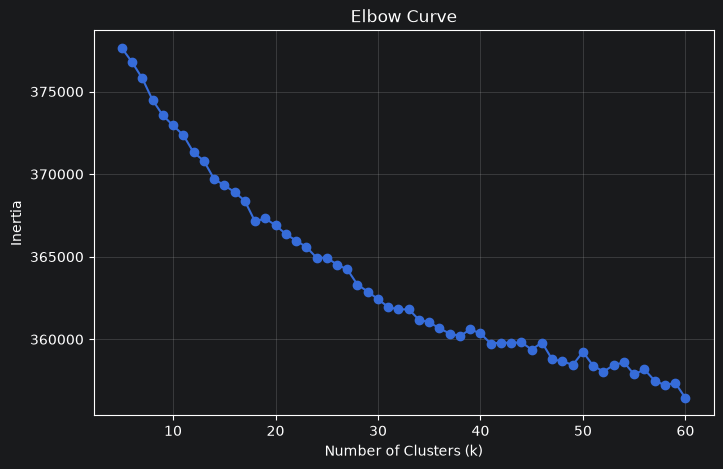

In [82]:
# Make elbow plot
plt.figure(figsize=(8, 5))

plt.plot(
    range(5, 61),
    inertia_values,
    marker='o'
)

plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Curve')

plt.grid(alpha=0.3)

plt.show()

In [83]:
# Take sample to use for UMAP
sample_size = 20000

sample_idx = df_narratives.sample(
    n=sample_size,
    random_state=42
).index

X_sample = X_tfidf[sample_idx]
cluster_sample = df_narratives.loc[sample_idx, 'cluster']

In [84]:
# Run SVD on 20k sample
svd = TruncatedSVD(
    n_components=50,
    random_state=42
)

X_sample_svd = svd.fit_transform(X_sample)

In [85]:
# Run UMAP
umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric='cosine',
    random_state=42
)

X_umap = umap_model.fit_transform(X_sample_svd)

C:\Users\Tony\PyCharm Projects\cfpb_mortgage_complaints\.venv312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


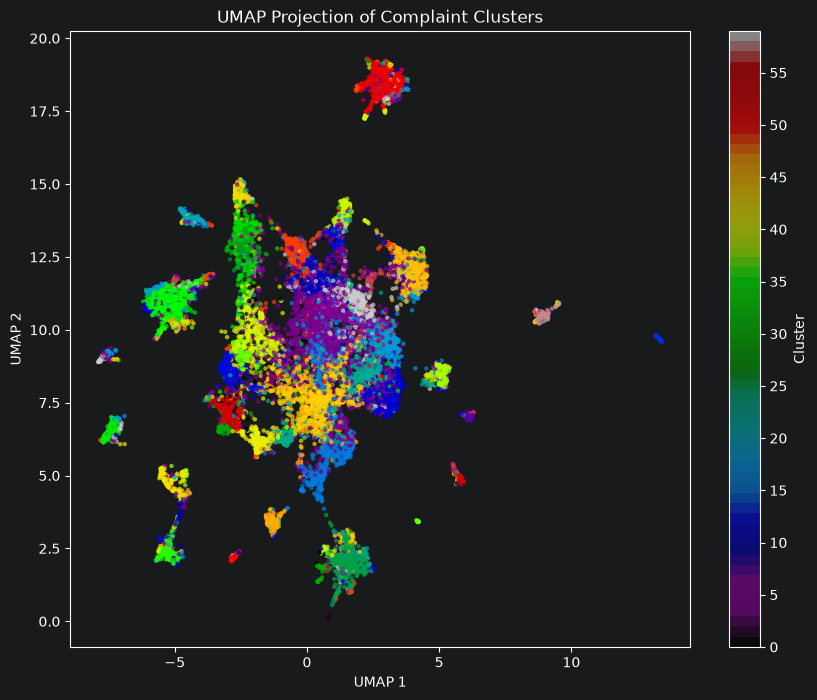

In [97]:
k = 60

cmap = plt.colormaps['nipy_spectral'].resampled(k)

plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=cluster_sample,
    cmap=cmap,
    s=5,
    alpha=0.6
)

plt.title('UMAP Projection of Complaint Clusters')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')

cbar = plt.colorbar(
    scatter,
    ticks=range(0, k, 5)
)

cbar.set_label('Cluster')

plt.show()

## Experimenting with Different Values of K

In [87]:
# # Run K-Means mini-batching and add cluster ID's to dataframe
# k = 10
#
# kmeans = MiniBatchKMeans(
#     n_clusters=k,
#     random_state=42,
#     batch_size=1000,
#     n_init='auto'
# )
#
# clusters = kmeans.fit_predict(X_tfidf)
#
# df_narratives['cluster'] = clusters
#
# df_narratives['cluster'].value_counts().sort_index()

In [88]:
# # Try different values of k (5, 10, 15, 20)
#
# # Use a sample for silhouette scoring to avoid memory/runtime issues
# sample_size = 10_000
#
# sample_idx = df_narratives.sample(
#     n=sample_size,
#     random_state=42
# ).index
#
# X_sample = X_tfidf[sample_idx]
#
# k_values = [5, 10, 15, 20]
#
# results = []
#
# for k in k_values:
#     print(f'Running MiniBatchKMeans for k={k}...')
#
#     kmeans = MiniBatchKMeans(
#         n_clusters=k,
#         random_state=42,
#         batch_size=1000,
#         n_init='auto'
#     )
#
#     cluster_labels = kmeans.fit_predict(X_tfidf)
#
#     sample_labels = cluster_labels[sample_idx]
#
#     sil_score = silhouette_score(
#         X_sample,
#         sample_labels,
#         metric='cosine'
#     )
#
#     results.append({
#         'k': k,
#         'silhouette_score': sil_score,
#         'inertia': kmeans.inertia_
#     })
#
#     print(f'k={k}, silhouette={sil_score:.4f}, inertia={kmeans.inertia_:.2f}')
#
# k_results = pd.DataFrame(results)
#
# k_results

In [89]:
# # Try different values of k (20, 25, 30)
#
# # Use a sample for silhouette scoring to avoid memory/runtime issues
# sample_size = 10_000
#
# sample_idx = df_narratives.sample(
#     n=sample_size,
#     random_state=42
# ).index
#
# X_sample = X_tfidf[sample_idx]
#
# k_values = [20, 25, 30]
#
# results = []
#
# for k in k_values:
#     print(f'Running MiniBatchKMeans for k={k}...')
#
#     kmeans = MiniBatchKMeans(
#         n_clusters=k,
#         random_state=42,
#         batch_size=1000,
#         n_init='auto'
#     )
#
#     cluster_labels = kmeans.fit_predict(X_tfidf)
#
#     sample_labels = cluster_labels[sample_idx]
#
#     sil_score = silhouette_score(
#         X_sample,
#         sample_labels,
#         metric='cosine'
#     )
#
#     results.append({
#         'k': k,
#         'silhouette_score': sil_score,
#         'inertia': kmeans.inertia_
#     })
#
#     print(f'k={k}, silhouette={sil_score:.4f}, inertia={kmeans.inertia_:.2f}')
#
# k_results = pd.DataFrame(results)
#
# k_results

In [90]:
# # Re-run K-Means with k = 30
# k = 30
#
# kmeans_30 = MiniBatchKMeans(
#     n_clusters=k,
#     random_state=42,
#     batch_size=1000,
#     n_init='auto'
# )
#
# df_narratives['cluster_30'] = kmeans_30.fit_predict(X_tfidf)

In [91]:
# # Get top terms for each cluster
# terms = np.array(tfidf.get_feature_names_out())
#
# for cluster_num in range(k):
#     top_indices = kmeans_30.cluster_centers_[cluster_num].argsort()[::-1][:15]
#     top_terms = terms[top_indices]
#
#     print(f'\nCluster {cluster_num}')
#     print(', '.join(top_terms))

In [92]:
# # Make elbow plot
#
# # If you already have k_results from the previous runs:
# k_results_all = pd.DataFrame({
#     'k': [5, 10, 15, 20, 25, 30],
#     'inertia': [
#         501625.757038,
#         493061.541536,
#         484974.411374,
#         477933.852704,
#         473501.325696,
#         469830.685334
#     ],
#     'silhouette_score': [
#         0.017681,
#         0.020211,
#         0.024968,
#         0.032750,
#         0.034799,
#         0.040312
#     ]
# })
#
# plt.figure(figsize=(8, 5))
#
# plt.plot(
#     k_results_all['k'],
#     k_results_all['inertia'],
#     marker='o'
# )
#
# plt.title('Elbow Plot for MiniBatchKMeans')
# plt.xlabel('Number of Clusters (k)')
# plt.ylabel('Inertia')
# plt.xticks(k_results_all['k'])
# plt.show()

In [93]:
# # Reuse the same 10k sample for silhouette scoring
# sample_idx = df_narratives.sample(
#     n=10000,
#     random_state=42
# ).index
#
# X_sample = X_tfidf[sample_idx]
#
# k_values = [10, 20, 30, 40, 50, 75]
#
# results = []
#
# for k in k_values:
#
#     print(f'Running MiniBatchKMeans for k={k}...')
#
#     model = MiniBatchKMeans(
#         n_clusters=k,
#         random_state=42,
#         batch_size=1000,
#         n_init='auto'
#     )
#
#     labels = model.fit_predict(X_tfidf)
#
#     sil = silhouette_score(
#         X_sample,
#         labels[sample_idx],
#         metric='cosine'
#     )
#
#     results.append({
#         'k': k,
#         'silhouette_score': sil,
#         'inertia': model.inertia_
#     })
#
#     print(
#         f'k={k}, '
#         f'silhouette={sil:.4f}, '
#         f'inertia={model.inertia_:.2f}'
#     )
#
# k_results = pd.DataFrame(results)
#
# print(k_results)

In [94]:
df_narratives.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,...,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID,cleaned_consumer_narrative,processed_narrative,cluster,distance_to_centroid
0,2019-11-18,Credit card or prepaid card,General-purpose credit card or charge card,Problem with a purchase shown on your statement,Credit card company isn't resolving a dispute ...,XXXX claimed they delivered a package to my ad...,NaN,DISCOVER BANK,MA,021XX,...,Web,2019-11-18,Closed with explanation,True,N/A,3442136,REDACTED claimed they delivered a package to m...,claimed delivered package address never receiv...,11,0.992864
1,2020-04-10,Credit card or prepaid card,General-purpose prepaid card,Trouble using the card,Trouble getting information about the card,I got a Brinks Money pre-paid card in the mail...,Company has responded to the consumer and the ...,Netspend Corporation,IL,60657,...,Web,2020-04-14,Closed with explanation,True,N/A,3601853,I got a Brinks Money pre-paid card in the mail...,got brink money pre paid card mail assuming un...,3,0.998468
2,2019-07-09,Credit card or prepaid card,Store credit card,Problem with a purchase shown on your statement,Card was charged for something you did not pur...,On XX/XX/XXXX I was called by a creditor Nelso...,NaN,Nelson Cruz & Associates LLC,TN,37043,...,Web,2019-07-09,Closed with explanation,True,N/A,3300820,On REDACTED_DATE I was called by a creditor Ne...,called creditor nelson cruz associate claimed ...,44,0.978543
3,2020-07-10,Credit card or prepaid card,General-purpose credit card or charge card,Trouble using your card,Can't use card to make purchases,Around XX/XX/2020 i XXXX XXXX XXXX opened a cr...,NaN,CAPITAL ONE FINANCIAL CORPORATION,CA,937XX,...,Web,2020-07-10,Closed with explanation,True,N/A,3739698,Around REDACTED / REDACTED /2020 i REDACTED RE...,around opened credit card account online capit...,25,0.852135
4,2019-06-24,Credit card or prepaid card,General-purpose credit card or charge card,"Advertising and marketing, including promotion...",Confusing or misleading advertising about the ...,Equifax sent me credit card suggestions to hel...,NaN,"EQUIFAX, INC.",OR,971XX,...,Web,2019-06-24,Closed with explanation,True,N/A,3285243,Equifax sent me credit card suggestions to hel...,equifax sent credit card suggestion help impro...,44,0.963603


In [95]:
df_narratives.info()

<class 'pandas.DataFrame'>
RangeIndex: 398004 entries, 0 to 398003
Data columns (total 22 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   Date received                 398004 non-null  datetime64[ms]
 1   Product                       398004 non-null  str           
 2   Sub-product                   398004 non-null  str           
 3   Issue                         398004 non-null  str           
 4   Sub-issue                     398004 non-null  str           
 5   Consumer complaint narrative  398004 non-null  str           
 6   Company public response       188952 non-null  str           
 7   Company                       398004 non-null  str           
 8   State                         398004 non-null  str           
 9   ZIP code                      398004 non-null  str           
 10  Tags                          83030 non-null   str           
 11  Consumer consent provide

In [102]:
df_narratives['cluster'].value_counts().sort_index(ascending=False)

cluster
59    14692
58     3797
57     3195
56     3186
55     8323
54        1
53     1611
52    14365
51      736
50     2580
49    11878
48        1
47     3795
46     4354
45    12061
44    23788
43     5717
42     6413
41     4910
40    13208
39     5635
38     6356
37     4491
36     5717
35    15604
34     6427
33        1
32    10975
31     2126
30        1
29        1
28     3134
27        1
26     6900
25    14668
24     1664
23     4408
22    11651
21     1695
20     5364
19     2209
18    11349
17        1
16     8986
15    10847
14        1
13     1379
12    10705
11    12998
10    10771
9      2682
8         2
7      2735
6     23631
5      2912
4      1166
3     45850
2         1
1       497
0      3852
Name: count, dtype: int64

In [96]:
OUTPUT_PATH = '../data/processed/clustered_narratives.parquet'

df_narratives.to_parquet(
    OUTPUT_PATH,
    index=False
)